In [16]:
import scanpy as sc
import anndata as ad
import seaborn as sns

In [17]:

adata=sc.read_loom('Integrated_betas.loom') 
adata.obs_names=adata.obs.obs_names
adata.var_names=adata.var.gene_name

C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
# Donors with at least 30 cells
keep_donors = adata.obs["Donor"].value_counts().loc[lambda x: x >= 30].index

# Filter AnnData
adata = adata[adata.obs["Donor"].isin(keep_donors)].copy()

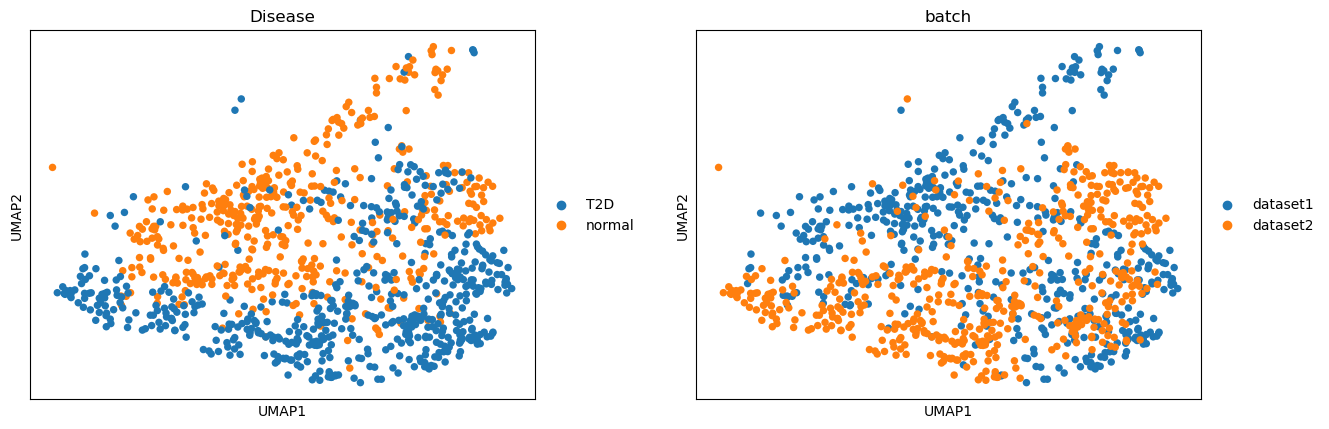

In [4]:
sc.pl.umap(adata, color=['Disease', 'batch'],wspace=0.2)


In [5]:
adata.obs.Disease.value_counts()

Disease
T2D       582
normal    456
Name: count, dtype: int64

In [6]:
import numpy as np
import pandas as pd

group = adata.obs["Disease"] == "T2D"
ref = ~group

X_group = adata[group].X
X_ref = adata[ref].X

# densify if sparse
if hasattr(X_group, "toarray"):
    X_group = X_group.toarray()
if hasattr(X_ref, "toarray"):
    X_ref = X_ref.toarray()

mean_group = (2**X_group - 1).mean(axis=0)
mean_ref   = (2**X_ref   - 1).mean(axis=0)

log2fc = np.log2((mean_group + 1) / (mean_ref + 1))

In [7]:
df_logfc=pd.DataFrame(log2fc, index=adata.var_names, columns=['logFC'])

In [8]:
df_logfc.sort_values(by='logFC')

,logFC
gene_name,
MTRNR2L1,-6.235004
IGFBP3,-5.172282
HILPDA,-3.551417
ARRDC3,-2.751811
TGM2,-2.749493
...,...
ST3GAL3,2.511422
TMEM59L,2.632018
HLA-DQB1,2.745369


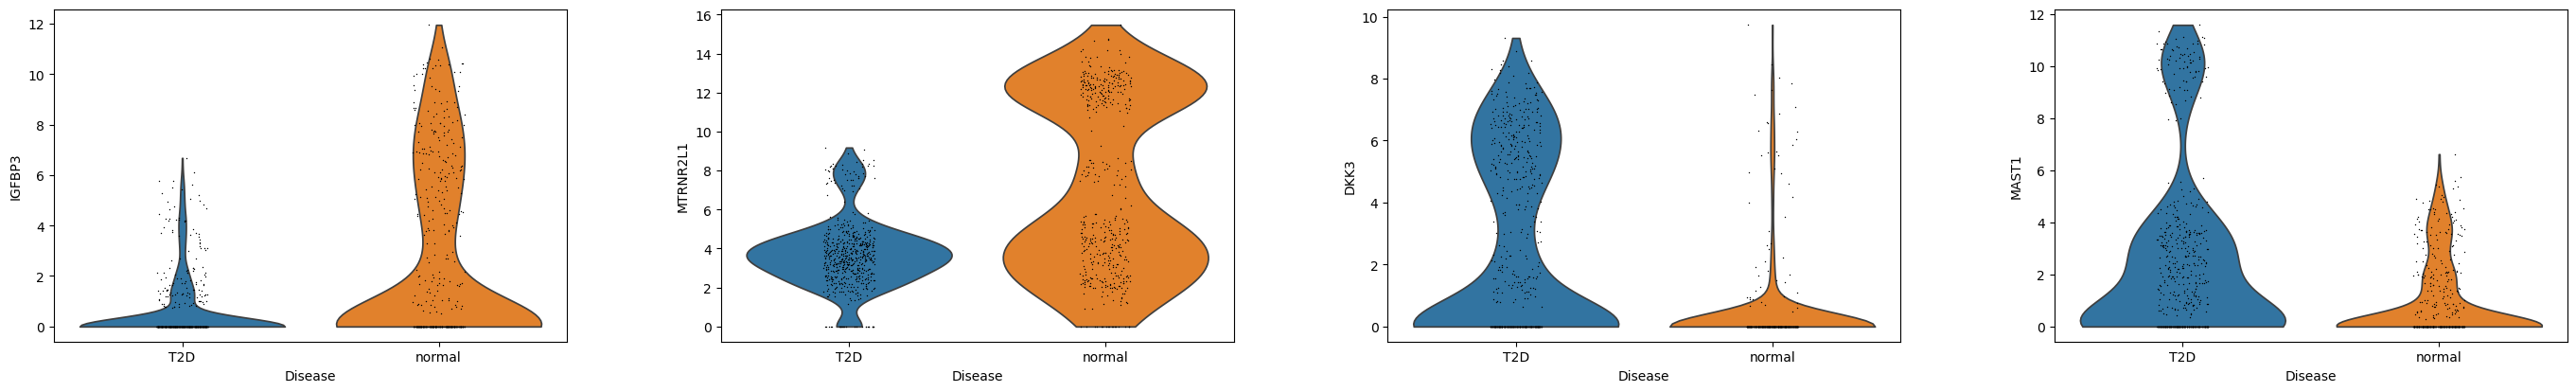

In [9]:
# Largest fold changes
sc.pl.violin(adata,keys=['IGFBP3','MTRNR2L1', 'DKK3','MAST1'], groupby='Disease')

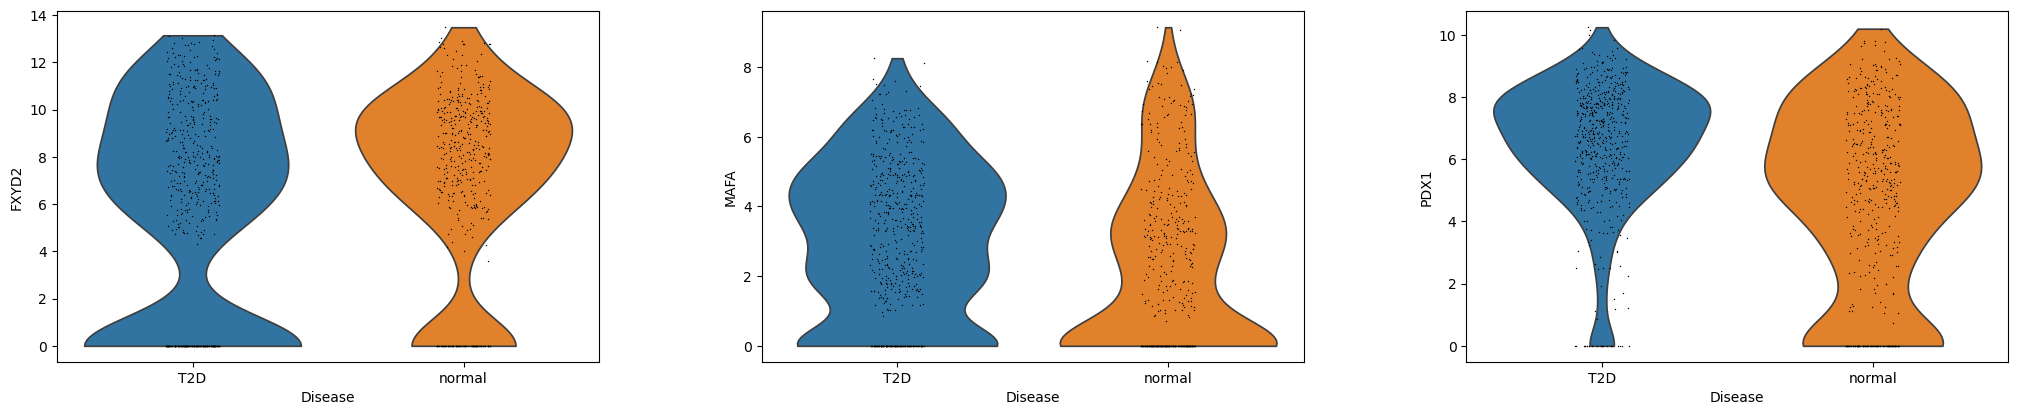

In [10]:
# Reported genes
sc.pl.violin(adata,keys=['FXYD2', 'MAFA','PDX1'], groupby='Disease')

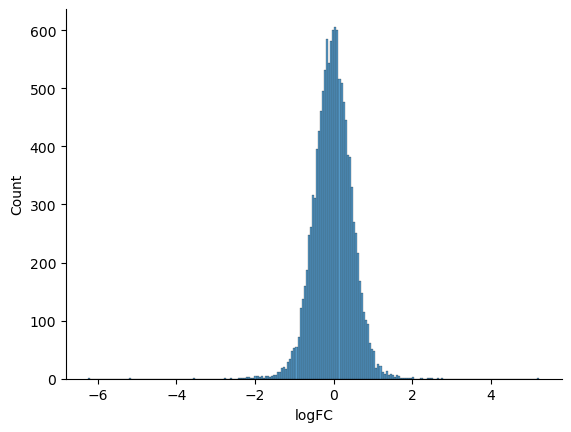

In [11]:
sns.histplot(df_logfc, x='logFC')
sns.despine()

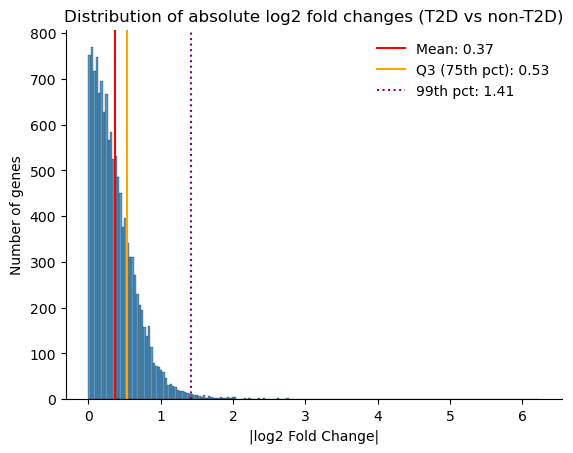

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

abs_logfc = df_logfc.logFC.abs()

stats = {
    "Mean": abs_logfc.mean(),
    "Q3 (75th pct)": abs_logfc.quantile(0.75),
    "99th pct": abs_logfc.quantile(0.99),
}

colors = ["red", "orange", "purple"]
linestyles = ["-", "-", ":"]

fig, ax = plt.subplots()
sns.histplot(abs_logfc, ax=ax)

for (label, value), color, ls in zip(stats.items(), colors, linestyles):
    ax.axvline(value, color=color, linestyle=ls, linewidth=1.5,
               label=f"{label}: {value:.2f}")

ax.set_xlabel("|log2 Fold Change|")
ax.set_ylabel("Number of genes")
ax.set_title("Distribution of absolute log2 fold changes (T2D vs non-T2D)")
ax.legend(frameon=False)

sns.despine()
plt.savefig('logFc_dist.png')
plt.savefig('logFc_dist.svg')
plt.show()

In [13]:
df_logfc.to_csv('Integrated_logFC.csv')

In [14]:
df_logfc

,logFC
gene_name,
FOXJ2,0.200574
ZNF654,-0.620239
ZMYM2,-0.218504
DCAF6,-0.085899
PDP1,-0.410657
...,...
MIEF1,0.163076
PLEKHO1,-0.971148
MEIS1-AS2,-0.094856


In [15]:
adata.obs.Donor

obs_names
351                    Sample110
352                    Sample102
353                    Sample102
355                    Sample110
358                    Sample108
                        ...     
HP1529801T2D_O17    HP1529801T2D
HP1529801T2D_O19    HP1529801T2D
HP1529801T2D_O21    HP1529801T2D
HP1529801T2D_O24    HP1529801T2D
HP1529801T2D_O6     HP1529801T2D
Name: Donor, Length: 1038, dtype: category
Categories (17, object): ['HP1525901', 'HP1529801T2D', 'HP1601201T2D', 'HP1602301T2D', ..., 'Sample106', 'Sample108', 'Sample109', 'Sample110']